In [1]:
import pandas as pd
df=pd.read_csv(r'/content/drive/MyDrive/Datasets/Wholesale customers data.csv')
df

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


In [2]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [9]:
x=df.copy()

In [10]:
from sklearn.preprocessing import MinMaxScaler
scale=MinMaxScaler()
x_scaled=scale.fit_transform(x)

In [11]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,6):
  km=KMeans(n_clusters=i,random_state=11)
  km.fit(x_scaled)
  wcss.append(km.inertia_)
print(wcss)

[186.89185814102905, 85.11692833765339, 41.73172344212007, 26.542897831987613, 21.746762042487163]


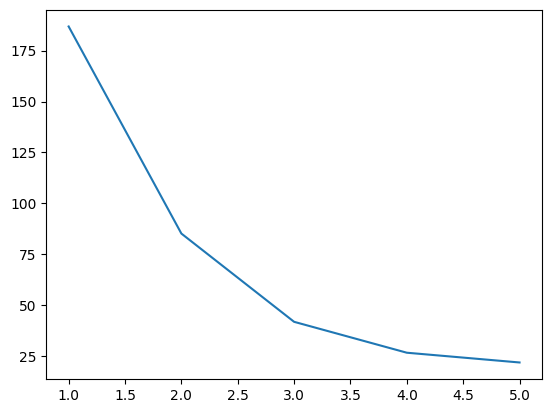

In [12]:
import matplotlib.pyplot as plt
plt.plot(range(1,6),wcss)

In [20]:
km=KMeans(n_clusters=4,random_state=11)
y=km.fit_predict(x_scaled)

In [21]:
from sklearn.metrics import silhouette_score
print(silhouette_score(x_scaled,y))

0.679962733411163


In [22]:
df['cluster']=y

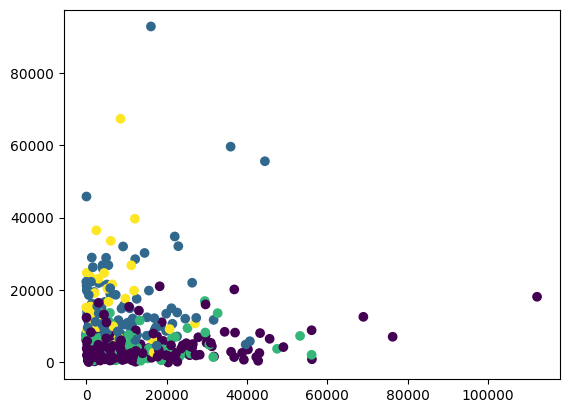

In [23]:
plt.scatter(x=df['Fresh'],y=df['Grocery'],c=df['cluster'])
plt.show()